# Scam-Message Classifier — Initial Model
Classical ML (TF-IDF + Logistic Regression / Random Forest) that classifies a short message as **advance-fee fraud**, **mobile-money fraud**, **phishing**, or **not-a-scam**.

*Initial/preliminary model trained on source-provenance labels (Nazario, MOZ-Smishing, Mendeley smishing, UCI). The final evaluation uses the human inter-rater-verified corpus.*

## 1 · Data engineering

In [1]:
import sys, json
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sys.path.insert(0, str(Path.cwd().parent))
from src import demo_model as dm
sns.set_theme(style='whitegrid')
df = dm.load_df()
print(f'{len(df):,} labelled messages')
df.head(4)

4,422 labelled messages


,id,text,language,category,source
0,c791fe9c85b3,Fifth Third Bank: account confirmation procedure.,en,phishing,nazario_email
1,cdeaa974dff3,Jesus armand really is trying to tell everybod...,en,not_a_scam,uci_sms
2,c81801dbc48c,Todays Vodafone numbers ending with 4865 are s...,en,advance_fee_fraud,mendeley_smishing
3,a414a6b7719e,It has issues right now. Ill fix for her by to...,en,not_a_scam,uci_sms


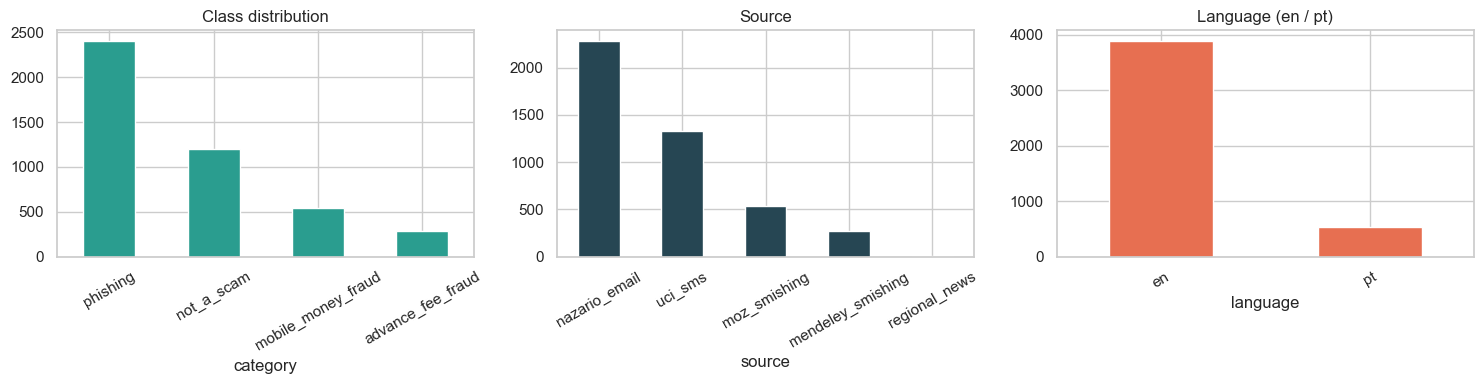

In [2]:
# Class distribution
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
df['category'].value_counts().plot.bar(ax=ax[0], color='#2a9d8f', title='Class distribution')
df['source'].value_counts().plot.bar(ax=ax[1], color='#264653', title='Source')
df['language'].value_counts().plot.bar(ax=ax[2], color='#e76f51', title='Language (en / pt)')
for a in ax: a.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

C:\Users\LENOVO\AppData\Local\Temp\claude\ipykernel_20612\1993969713.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['len']<800], x='category', y='len', palette='Set2')


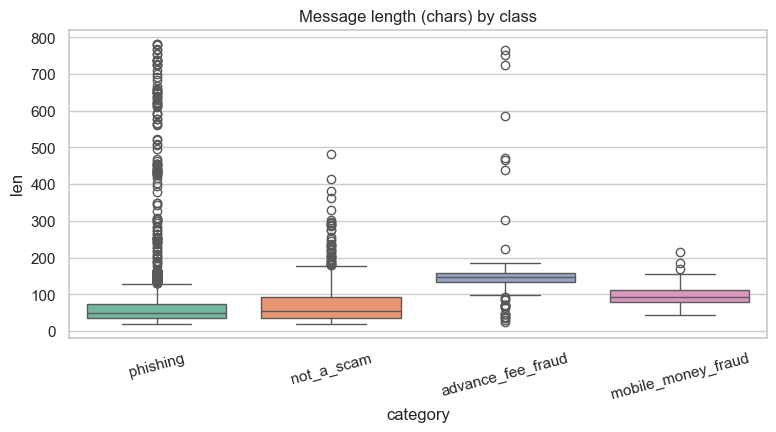

category
advance_fee_fraud     151.0
mobile_money_fraud     93.0
not_a_scam             53.0
phishing               53.0
Name: len, dtype: float64

In [3]:
# Message-length distribution by class
df['len'] = df['text'].str.len()
plt.figure(figsize=(9,4))
sns.boxplot(data=df[df['len']<800], x='category', y='len', palette='Set2')
plt.title('Message length (chars) by class'); plt.xticks(rotation=15); plt.show()
df.groupby('category')['len'].median()

**Provenance — which source feeds which class.** A category × source cross-tab. Shows the corpus design: the Portuguese MOZ set carries mobile-money, the email corpus carries phishing / advance-fee, UCI carries the benign negatives.

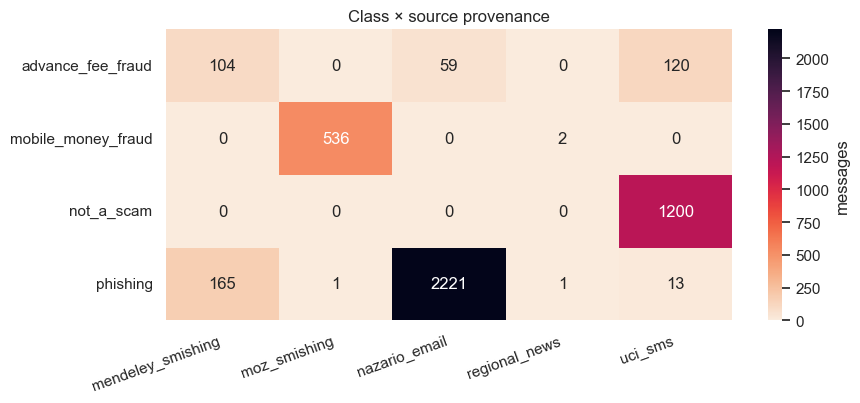

In [4]:
ct = pd.crosstab(df['category'], df['source'])
plt.figure(figsize=(9,4.2))
sns.heatmap(ct, annot=True, fmt='d', cmap='rocket_r', cbar_kws={'label':'messages'})
plt.title('Class × source provenance'); plt.ylabel(''); plt.xlabel('')
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

## 2 · Model architecture
Classical ML pipeline — chosen over deep networks per the approved methodology (interpretability, robustness on a small corpus, cheap low-resource deployment). Two classifiers share one feature representation.

**Feature extraction — TF-IDF.** Word 1–2 grams, `min_df=2`, sublinear term frequency (`1+log tf`), IDF weighting, unicode accent-stripping, vocabulary capped at 30,000 → each message becomes a sparse weighted n-gram vector.

**Model A — Logistic Regression.** Linear model whose decision function is a **softmax** over the 4 classes (multinomial analogue of a sigmoid activation). *Optimisation:* L2-regularised cross-entropy minimised by the **lbfgs** solver (quasi-Newton), inverse-reg `C=4`, `max_iter=2000`, `class_weight='balanced'`.

**Model B — Random Forest.** Ensemble of **500 CART trees**, **Gini** splits, trained by **bootstrap aggregation (bagging)** with random feature subsampling; prediction by majority vote. `class_weight='balanced'`.

**Training protocol.** 70/15/15 **stratified** split, fixed seed (42); metrics reported on the held-out test split.

In [5]:
train, dev, test = dm.split(df)
print(f'train {len(train)} / dev {len(dev)} / test {len(test)}')
pipes = dm.build_pipelines()
for name, p in pipes.items():
    p.fit(train['text'], train['category'])
print('fitted:', list(pipes))

train 3095 / dev 663 / test 664


fitted: ['tfidf_logreg', 'tfidf_rf']


## 3 · Performance metrics (held-out test set)

In [6]:
rows = []
for name, p in pipes.items():
    m = dm.evaluate(p, test['text'], test['category'])
    rows.append({'model': name, 'accuracy': round(m['accuracy'],3), 'macro_F1': round(m['macro_f1'],3)})
summary = pd.DataFrame(rows).set_index('model'); summary

,accuracy,macro_F1
model,,
tfidf_logreg,0.958,0.943
tfidf_rf,0.950,0.928


In [7]:
best_name = summary['macro_F1'].idxmax()
best = pipes[best_name]
print(f'Best model: {best_name}')
print(dm.evaluate(best, test['text'], test['category'])['report'])

Best model: tfidf_logreg
                    precision    recall  f1-score   support

 advance_fee_fraud       0.83      0.90      0.86        42
mobile_money_fraud       1.00      0.98      0.99        81
          phishing       0.98      0.94      0.96       361
        not_a_scam       0.93      0.99      0.96       180

          accuracy                           0.96       664
         macro avg       0.93      0.95      0.94       664
      weighted avg       0.96      0.96      0.96       664



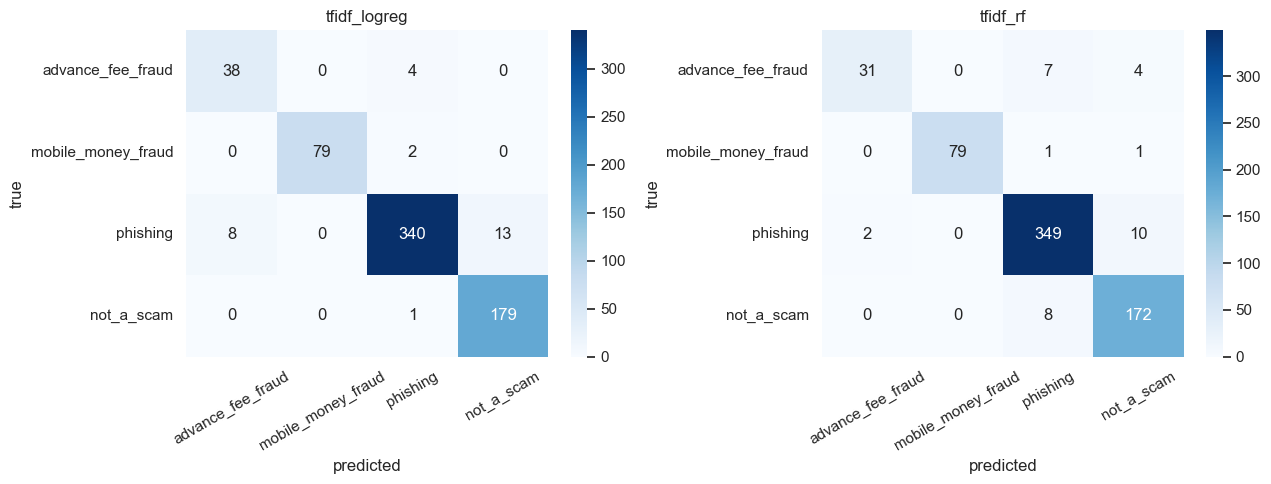

In [8]:
# Confusion matrices
from sklearn.metrics import confusion_matrix
fig, ax = plt.subplots(1, 2, figsize=(13,5))
for i,(name,p) in enumerate(pipes.items()):
    cm = confusion_matrix(test['category'], p.predict(test['text']), labels=dm.CLASS_ORDER)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[i],
                xticklabels=dm.CLASS_ORDER, yticklabels=dm.CLASS_ORDER)
    ax[i].set_title(f'{name}'); ax[i].set_xlabel('predicted'); ax[i].set_ylabel('true')
    ax[i].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## 4 · Per-class agreement — Logistic Regression vs Random Forest
F1 per class for both models on the test set (higher = better).

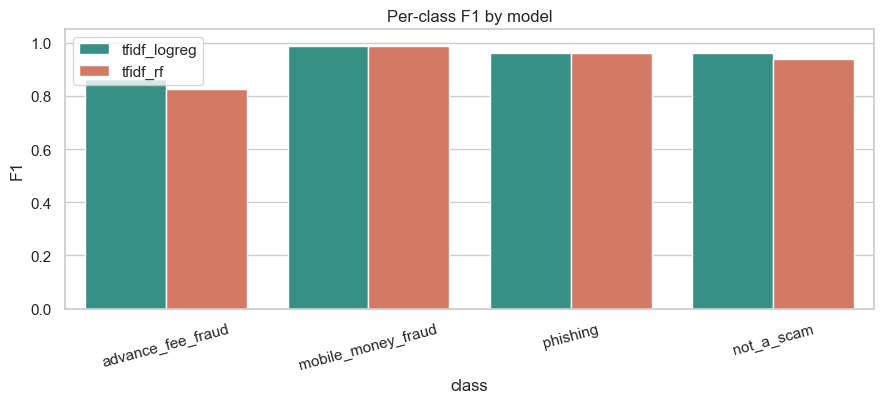

In [9]:
import pandas as pd
rowsf = []
for name, p in pipes.items():
    pc = dm.evaluate(p, test['text'], test['category'])['per_class']
    for c, m in pc.items():
        rowsf.append({'class': c, 'model': name, 'F1': m['f1']})
fdf = pd.DataFrame(rowsf)
plt.figure(figsize=(9,4.2))
sns.barplot(data=fdf, x='class', y='F1', hue='model', palette=['#2a9d8f','#e76f51'])
plt.ylim(0,1.05); plt.title('Per-class F1 by model'); plt.xticks(rotation=15)
plt.legend(title=''); plt.tight_layout(); plt.show()

## 5 · What the model keys on — top terms per class
Largest Logistic-Regression coefficients per class (the n-grams that most push a message toward each label).

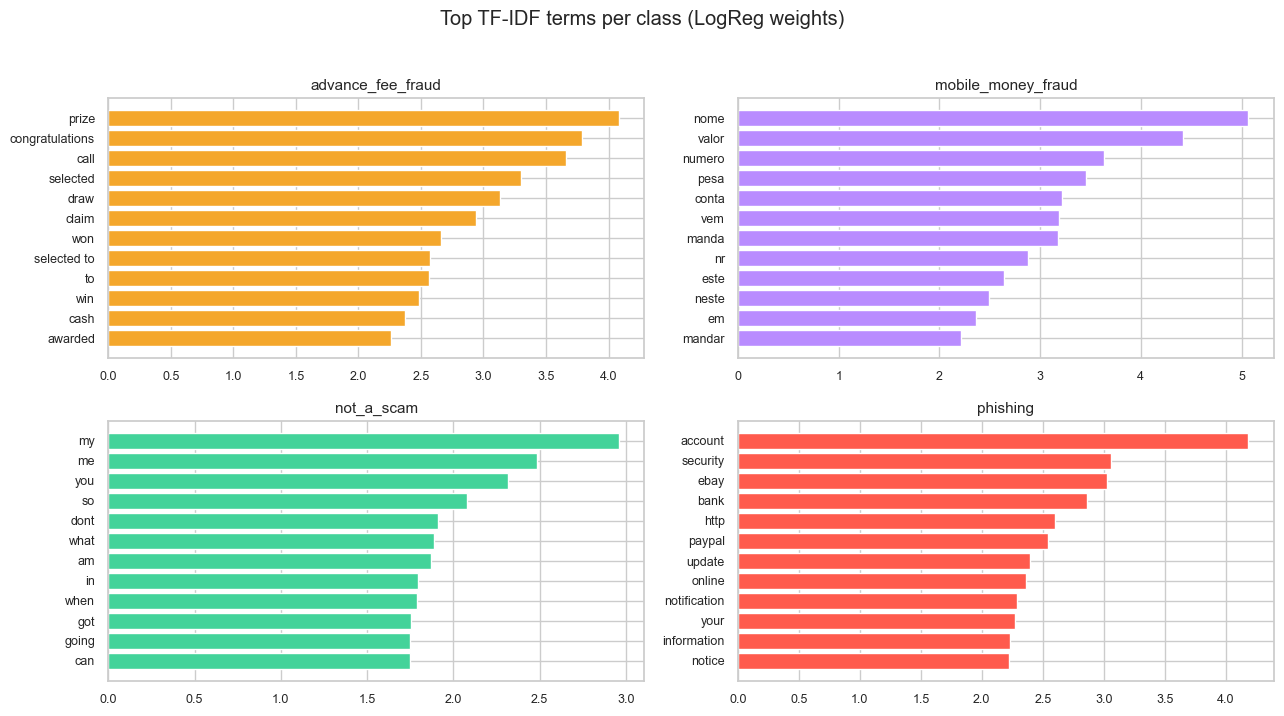

In [10]:
lr = pipes['tfidf_logreg']
vec = lr.named_steps['tfidf']; clf = lr.named_steps['clf']
feats = np.array(vec.get_feature_names_out())
fig, ax = plt.subplots(2, 2, figsize=(13, 7))
colors = {'phishing':'#ff5a4d','advance_fee_fraud':'#f4a72c',
          'mobile_money_fraud':'#b98cff','not_a_scam':'#43d39a'}
for a, c in zip(ax.ravel(), clf.classes_):
    idx = np.argsort(clf.coef_[list(clf.classes_).index(c)])[-12:]
    a.barh(feats[idx], clf.coef_[list(clf.classes_).index(c)][idx], color=colors.get(c,'#888'))
    a.set_title(c, fontsize=11); a.tick_params(labelsize=9)
plt.suptitle('Top TF-IDF terms per class (LogReg weights)', y=1.02)
plt.tight_layout(); plt.show()

## 6 · Live inference

In [11]:
examples = [
  'URGENT! Your mobile number won a 2000 prize GUARANTEED. Call 09061790121 to claim.',
  'Caro cliente, a sua conta M-Pesa foi bloqueada. Envie o seu PIN para reactivar.',
  'Dear customer, click here to verify your bank account or it will be suspended: http://bit.ly/x9',
  'Hey, are we still meeting for lunch at 1pm tomorrow?',
]
proba = best.predict_proba(examples); classes = list(best.classes_)
for t, pr in zip(examples, proba):
    s = sorted(zip(classes, pr), key=lambda x:-x[1])[0]
    print(f'{s[0]:18} ({s[1]:.2f})  <- {t[:60]}')

advance_fee_fraud  (0.99)  <- URGENT! Your mobile number won a 2000 prize GUARANTEED. Call
mobile_money_fraud (0.70)  <- Caro cliente, a sua conta M-Pesa foi bloqueada. Envie o seu 
phishing           (0.93)  <- Dear customer, click here to verify your bank account or it 
not_a_scam         (0.94)  <- Hey, are we still meeting for lunch at 1pm tomorrow?


## 7 · Deployment
The fitted pipeline is saved to `ml/models/scam_classifier.joblib` and served via **FastAPI** with interactive **Swagger UI**:

```bash
python -m uvicorn ml.serve.app:app --reload --port 8000
# open http://127.0.0.1:8000/docs  ->  POST /predict
```